# Random forest on pleasant days classification

## Table of contents
### [1. Libraries import and Data preparation](#1)
### [2. Random Forest Model on 10 years with all weather stations](#2)
#### [2.1 Splitting data in X and y](#2.1)
#### [2.2 Optimization of the Random forest on 10 years with all weather stations](#2.2)
#### [2.3 Optimized Random forest on 10 years with all weather stations](#2.3)
### [3. Random Forest Model on the top 3 important weather stations](#3)
#### [3.1 Automating the top 3 stations from the previous random forest](#3.1)
#### [3.2 Optimization search for Random forest on the top 3 important weather stations](#3.2)
#### [3.3 Optimized Random forest on the top 3 important weather stations](#3.3)


## 1. Libraries import and Data preparation
<div id='1'></div>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint
import time

##to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Creating paths to the data folder of the project and to the folder for saving the charts
path_data = r"C:\Users\dacol\Documents\Data_Project_careerfoundry\ClimateWins_ML\02 Data"

# Importing the cleaned dataset with the weather observations
df_weather = pd.read_pickle(os.path.join(path_data,'Prepared Data','Cleaned_ML_ready.pkl'))

# Importing the rated dataframe for pleasant days
df_rate = pd.read_csv(os.path.join(path_data,'Original Data','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'), sep =',')

In [7]:
print(df_weather.shape)
print(df_rate.shape)

(22950, 135)
(22950, 16)


In [9]:
df_weather.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_humidity,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,0.98,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,0.62,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,0.69,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,0.98,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,0.96,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [11]:
df_rate.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
# Select 10 consecutive years from df_rate
years = df_rate['DATE'].apply(lambda x: str(x)[:4]).unique()[:10]
df_rate_10_years = df_rate[df_rate['DATE'].apply(lambda x: str(x)[:4]).isin(years)]

# Filter data for each weather station individually
stations = [col.split('_')[0] for col in df_weather.columns if '_' in col]
unique_stations = list(set(stations))


## 2. Random Forest Model on 10 years with all weather stations:
<div id='2'></div>

### 2.1 Spliting data in X and y
<div id='2.1'></div>

In [17]:
# Define the shape of the data
X = df_weather.values

# Extract the target variable 'pleasant_weather' for each station
# Ensure the target variable matches the shape of the features
y = df_rate_10_years.iloc[:, 1:].values.flatten()

# Filter the target variable to match the number of samples in X
y = y[:X.shape[0]]

In [19]:
#splitting data into test and training subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2.2 Optimization search for the Random forest on 10 years with all weather stations
<div id='2.2'></div>

In [30]:
# Define the parameter grid for GridSearchCV
grid_space = {
    'max_depth': [3, 5, 10, None],
    'n_estimators': [10, 100, 200],
    'max_features': [1, 3, 5, 7],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [1, 2, 3],
    'criterion': ['gini', 'entropy']
}

In [32]:
# Initialize the GridSearchCV with the RandomForestClassifier
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=grid_space, cv=5, n_jobs=-1, verbose=2,scoring='accuracy')

In [34]:
start = time.time()
model_grid = grid_search.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Search took 16.85911190509796 minutes


In [37]:
# Get the best parameters and model accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Model Accuracy: {best_accuracy}")


Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best Model Accuracy: 0.8136165577342048


### 2.3 Optimized Random forest on 10 years with all weather stations
<div id='2.3'></div>

In [40]:
# Optimized parameters to be entered lanually from the above results
optimized_params = {
    'max_depth': None,
    'n_estimators': 100,
    'max_features': 7,
    'min_samples_leaf': 1,
    'min_samples_split': 3,
    'criterion': 'entropy'
}

In [42]:
# Initialize the RandomForestClassifier with optimized parameters
clf_optimized = RandomForestClassifier(
    max_depth=optimized_params['max_depth'],
    n_estimators=optimized_params['n_estimators'],
    max_features=optimized_params['max_features'],
    min_samples_leaf=optimized_params['min_samples_leaf'],
    min_samples_split=optimized_params['min_samples_split'],
    criterion=optimized_params['criterion'],
    random_state=42
)


In [44]:
# Fit the model to the training data
clf_optimized.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_features=7, min_samples_split=3,
                       random_state=42)

In [45]:
# Predict and evaluate the model with the optimized parameters
y_pred_optimized = clf_optimized.predict(X_test)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

print(f"Optimized Model Accuracy: {accuracy_optimized}")

Optimized Model Accuracy: 0.8098039215686275


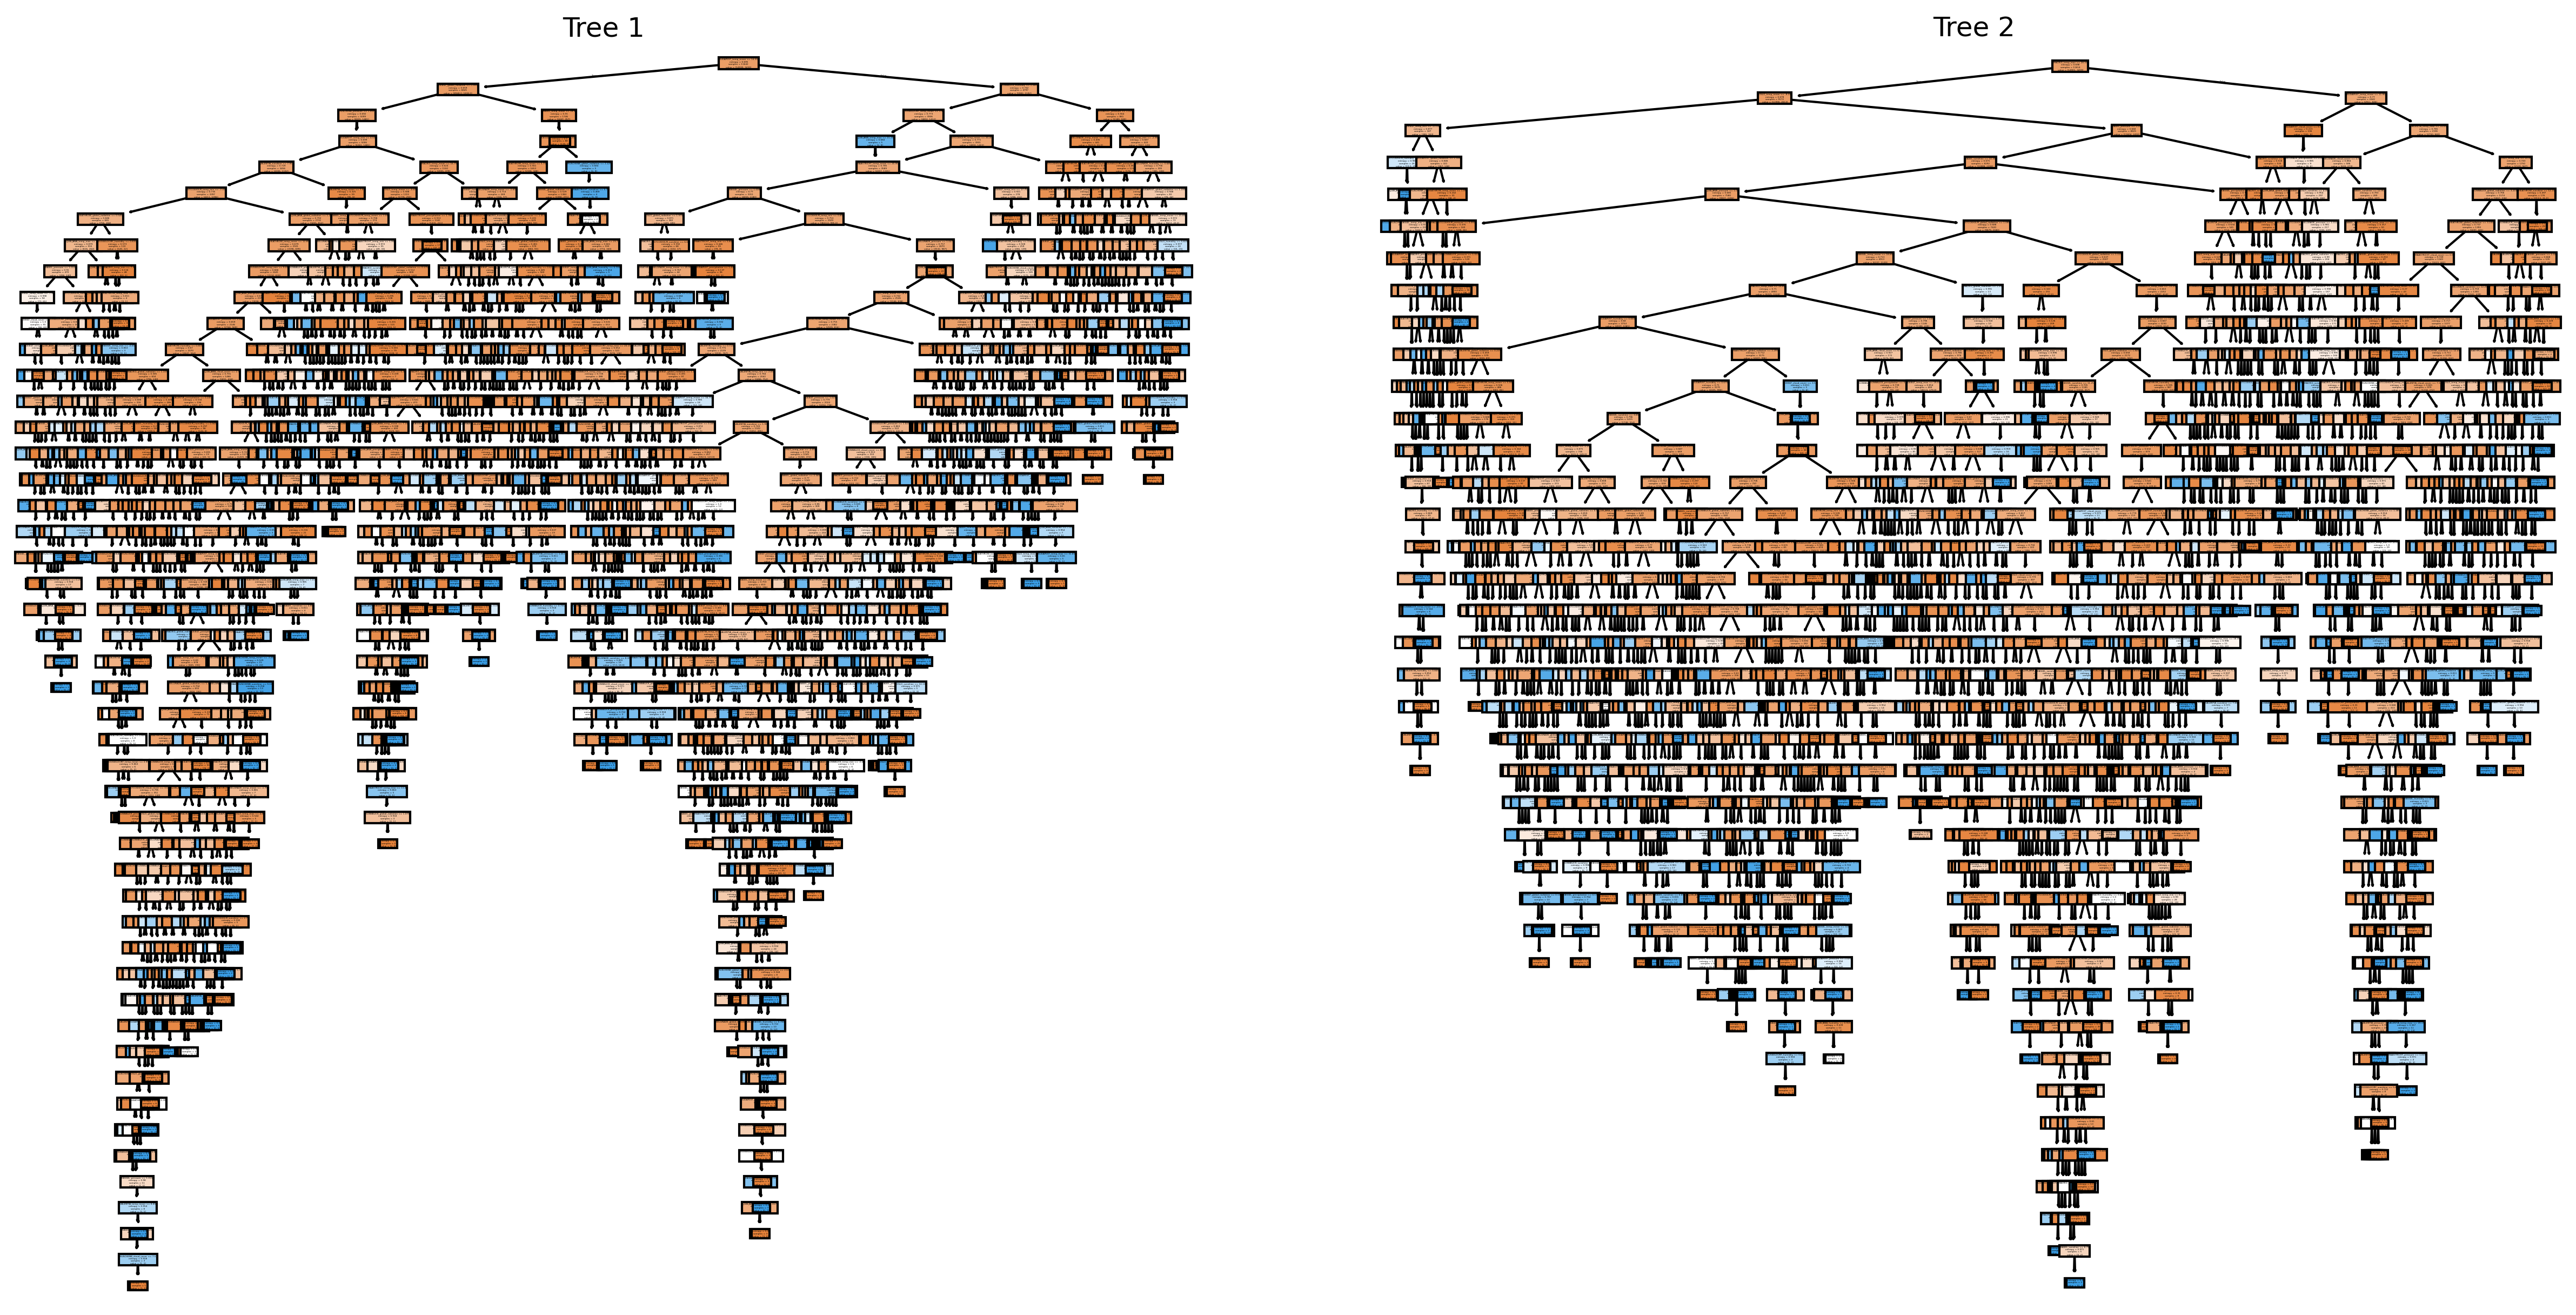

In [48]:
# Plot two different trees from the random forest model
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), dpi=300)
for index in range(2):
    plot_tree(clf_optimized.estimators_[index], ax=axes[index], feature_names=df_weather.columns, filled=True)
    axes[index].set_title(f"Tree {index + 1}")

# Save and show the plots
plt.savefig('random_forest_trees.png')
plt.show()


In [49]:
# Extract feature importances
importances = clf_optimized.feature_importances_

# Reshape the list to (-1, 15, 9)
importances_reshaped = importances.reshape(-1, 15, 9)

# Collapse the shape into one observation for each weather station
importances_collapsed = np.sum(importances_reshaped[0], axis=1)


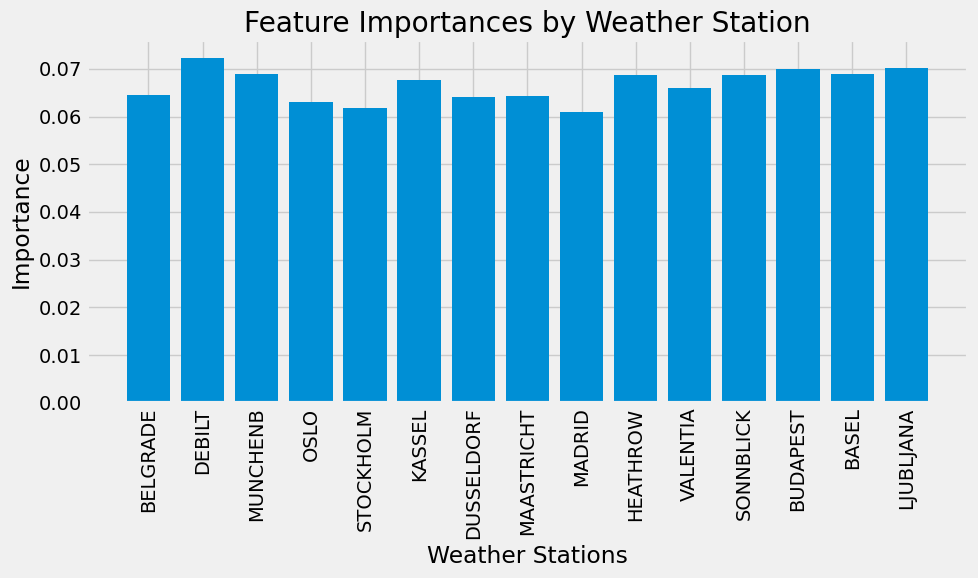

In [97]:
# Plot a bar chart of the importances against a list of the weather stations
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 6))
plt.bar(unique_stations, importances_collapsed)
plt.xlabel('Weather Stations')
plt.ylabel('Importance')
plt.title('Feature Importances by Weather Station')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()


## 3. Random Forest Model on the top 3 important weather stations:
<div id='3'></div>

### 3.1 Automating the top 3 stations from the previous random forest
<div id='3.1'></div>

In [56]:
# Identify top three stations
top_stations = np.argsort(importances_collapsed)[-3:]

# Create subsets for the top three stations
subsets = {}
for station in top_stations:
    station_name = unique_stations[station]
    subsets[station_name] = df_weather.filter(like=station_name)


### 3.2 Optimization search for Random forest on the top 3 important weather stations
<div id='3.2'></div>

In [60]:
# Define the parameter distribution for RandomizedSearchCV
param_dist = {'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 200, step=20),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [62]:
start = time.time()

# Train random forest model for each top station with random search optimization
best_params_dict = {}
for station_name, subset in subsets.items():
    # Ensure the target variable matches the shape of the features for the entire period
    y_station = df_rate[f"{station_name}_pleasant_weather"].values
    X_station = subset.values

    # Check if the shapes of X_station and y_station are consistent
    if X_station.shape[0] != y_station.shape[0]:
        print(f"Shape mismatch for {station_name}: X_station shape = {X_station.shape}, y_station shape = {y_station.shape}")
        continue

    X_train, X_test, y_train, y_test = train_test_split(X_station, y_station, test_size=0.2, random_state=42)

    # Initialize the RandomizedSearchCV with the RandomForestClassifier
    random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist, n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42)
    
    # Fit the RandomizedSearchCV to the training data
    random_search.fit(X_train, y_train)
    
    # Get the best parameters and model accuracy
    best_params_random = random_search.best_params_
    best_accuracy_random = random_search.best_score_

    best_params_dict[station_name] = best_params_random

    print(f"Best Parameters for {station_name}: {best_params_random}")
    print(f"Best Model Accuracy for {station_name}: {best_accuracy_random}")

print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for BUDAPEST: {'criterion': 'gini', 'max_depth': 40, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 360}
Best Model Accuracy for BUDAPEST: 1.0
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for LJUBLJANA: {'criterion': 'gini', 'max_depth': 40, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 360}
Best Model Accuracy for LJUBLJANA: 1.0
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for DEBILT: {'criterion': 'gini', 'max_depth': 40, 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 360}
Best Model Accuracy for DEBILT: 1.0
Search took 6.281522603829702 minutes


### 3.3 Optimized Random forest on the top 3 important weather stations
<div id='3.3'></div>

Optimized Model Accuracy for BUDAPEST: 1.0


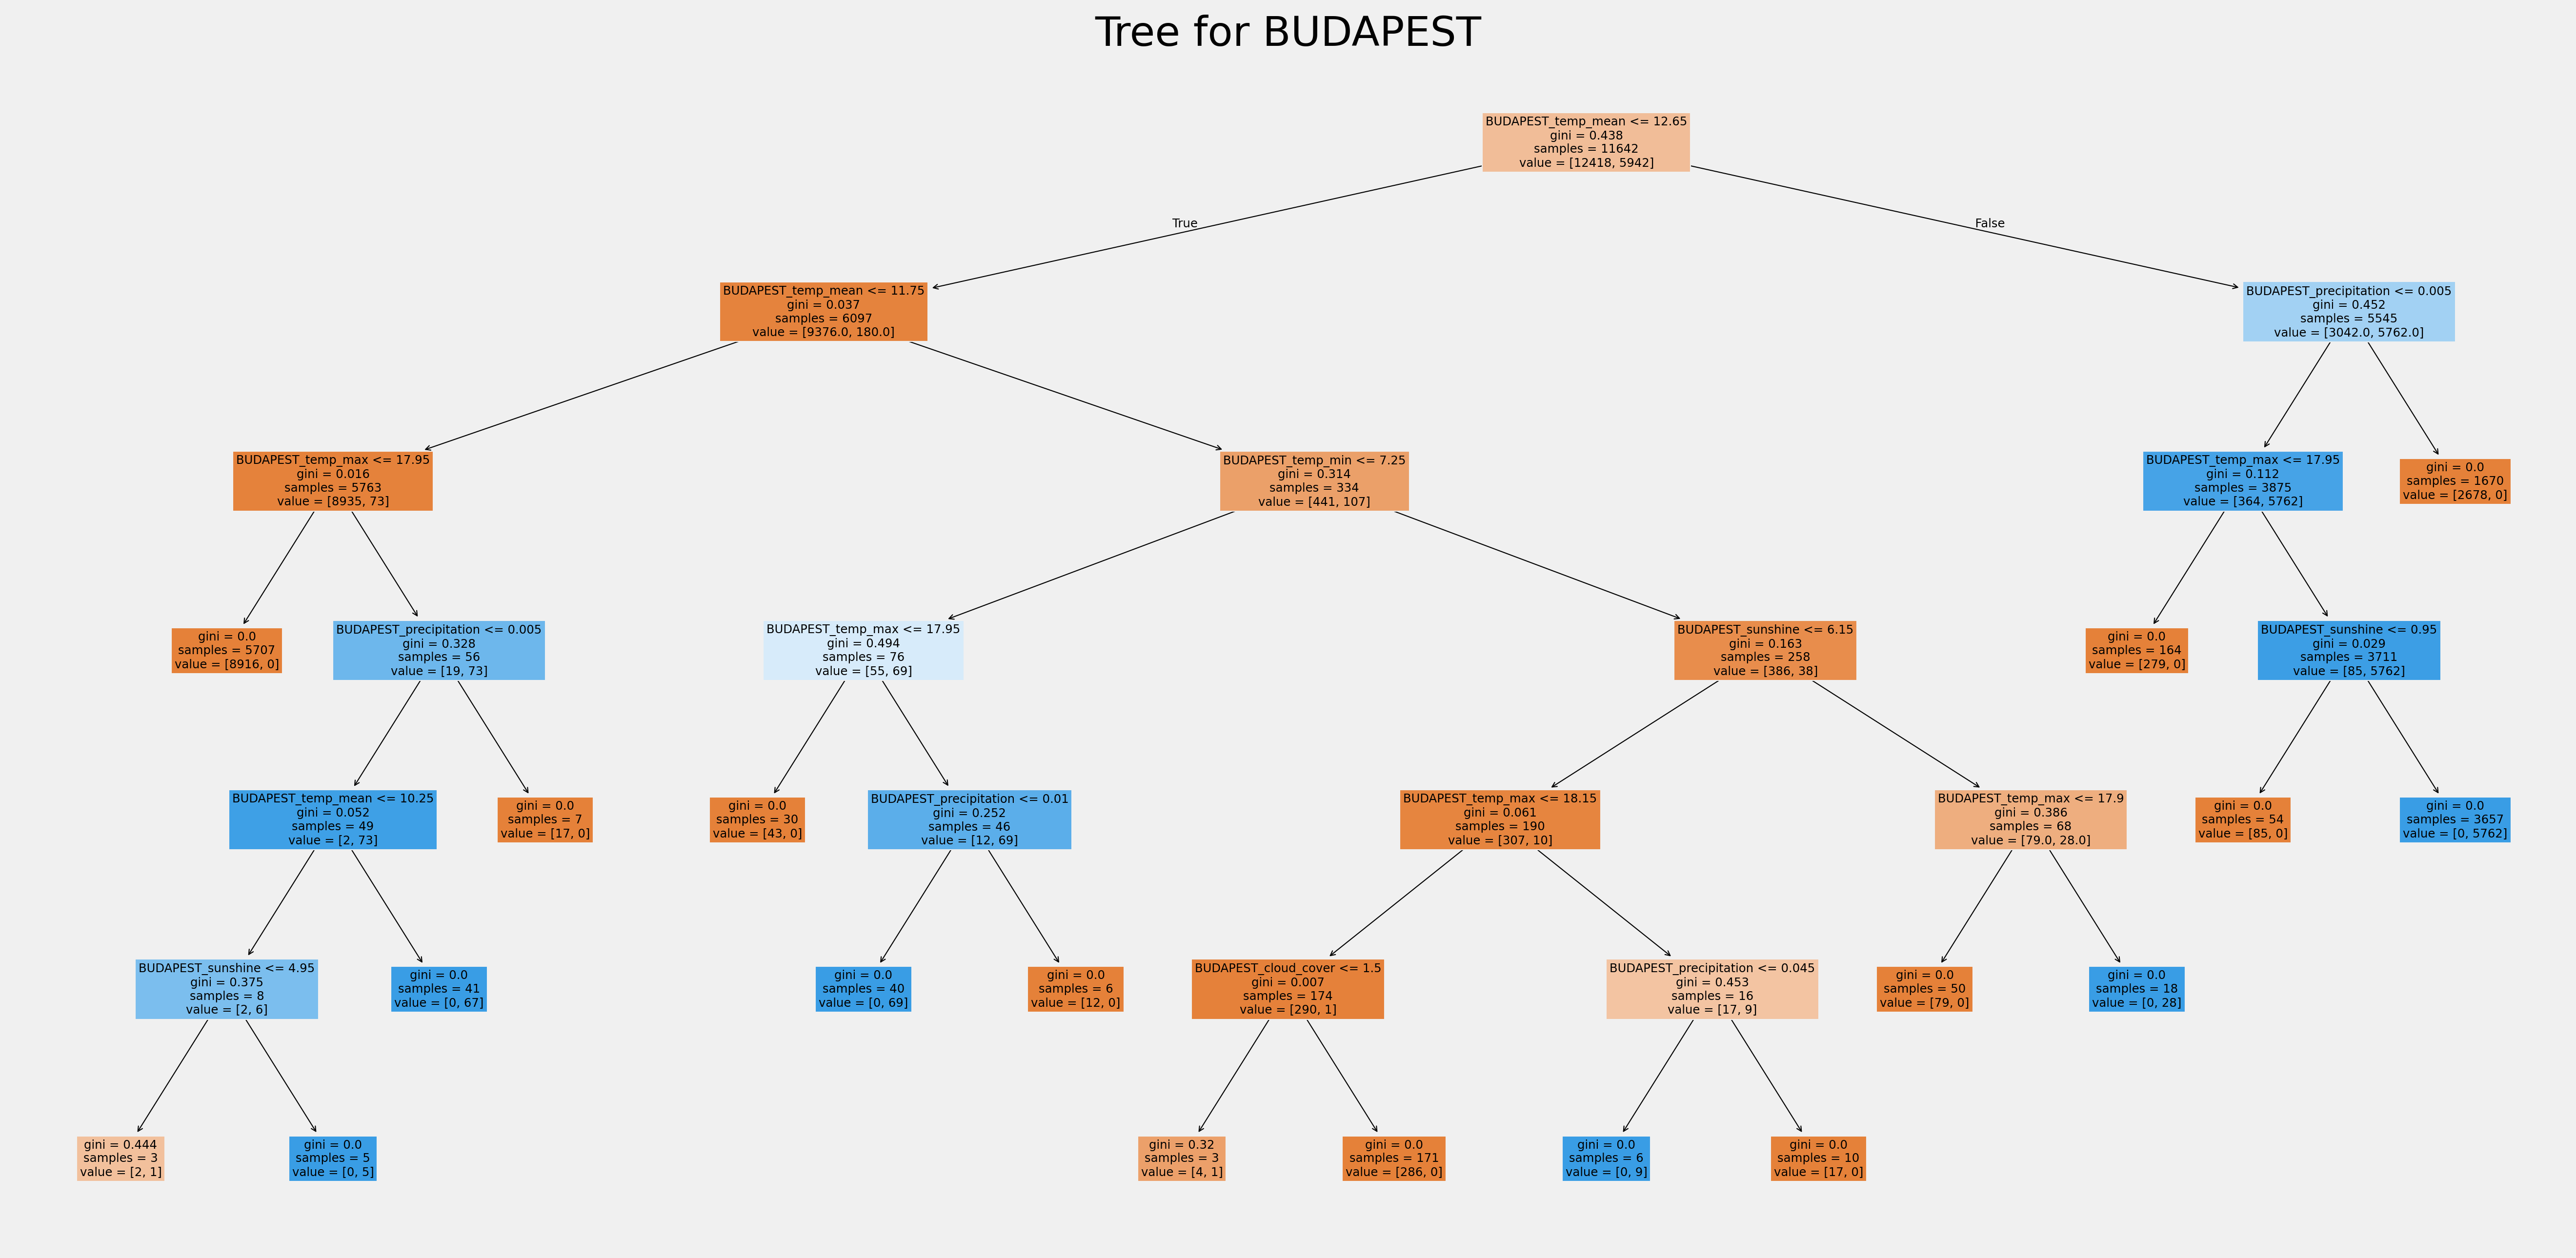

Optimized Model Accuracy for LJUBLJANA: 1.0


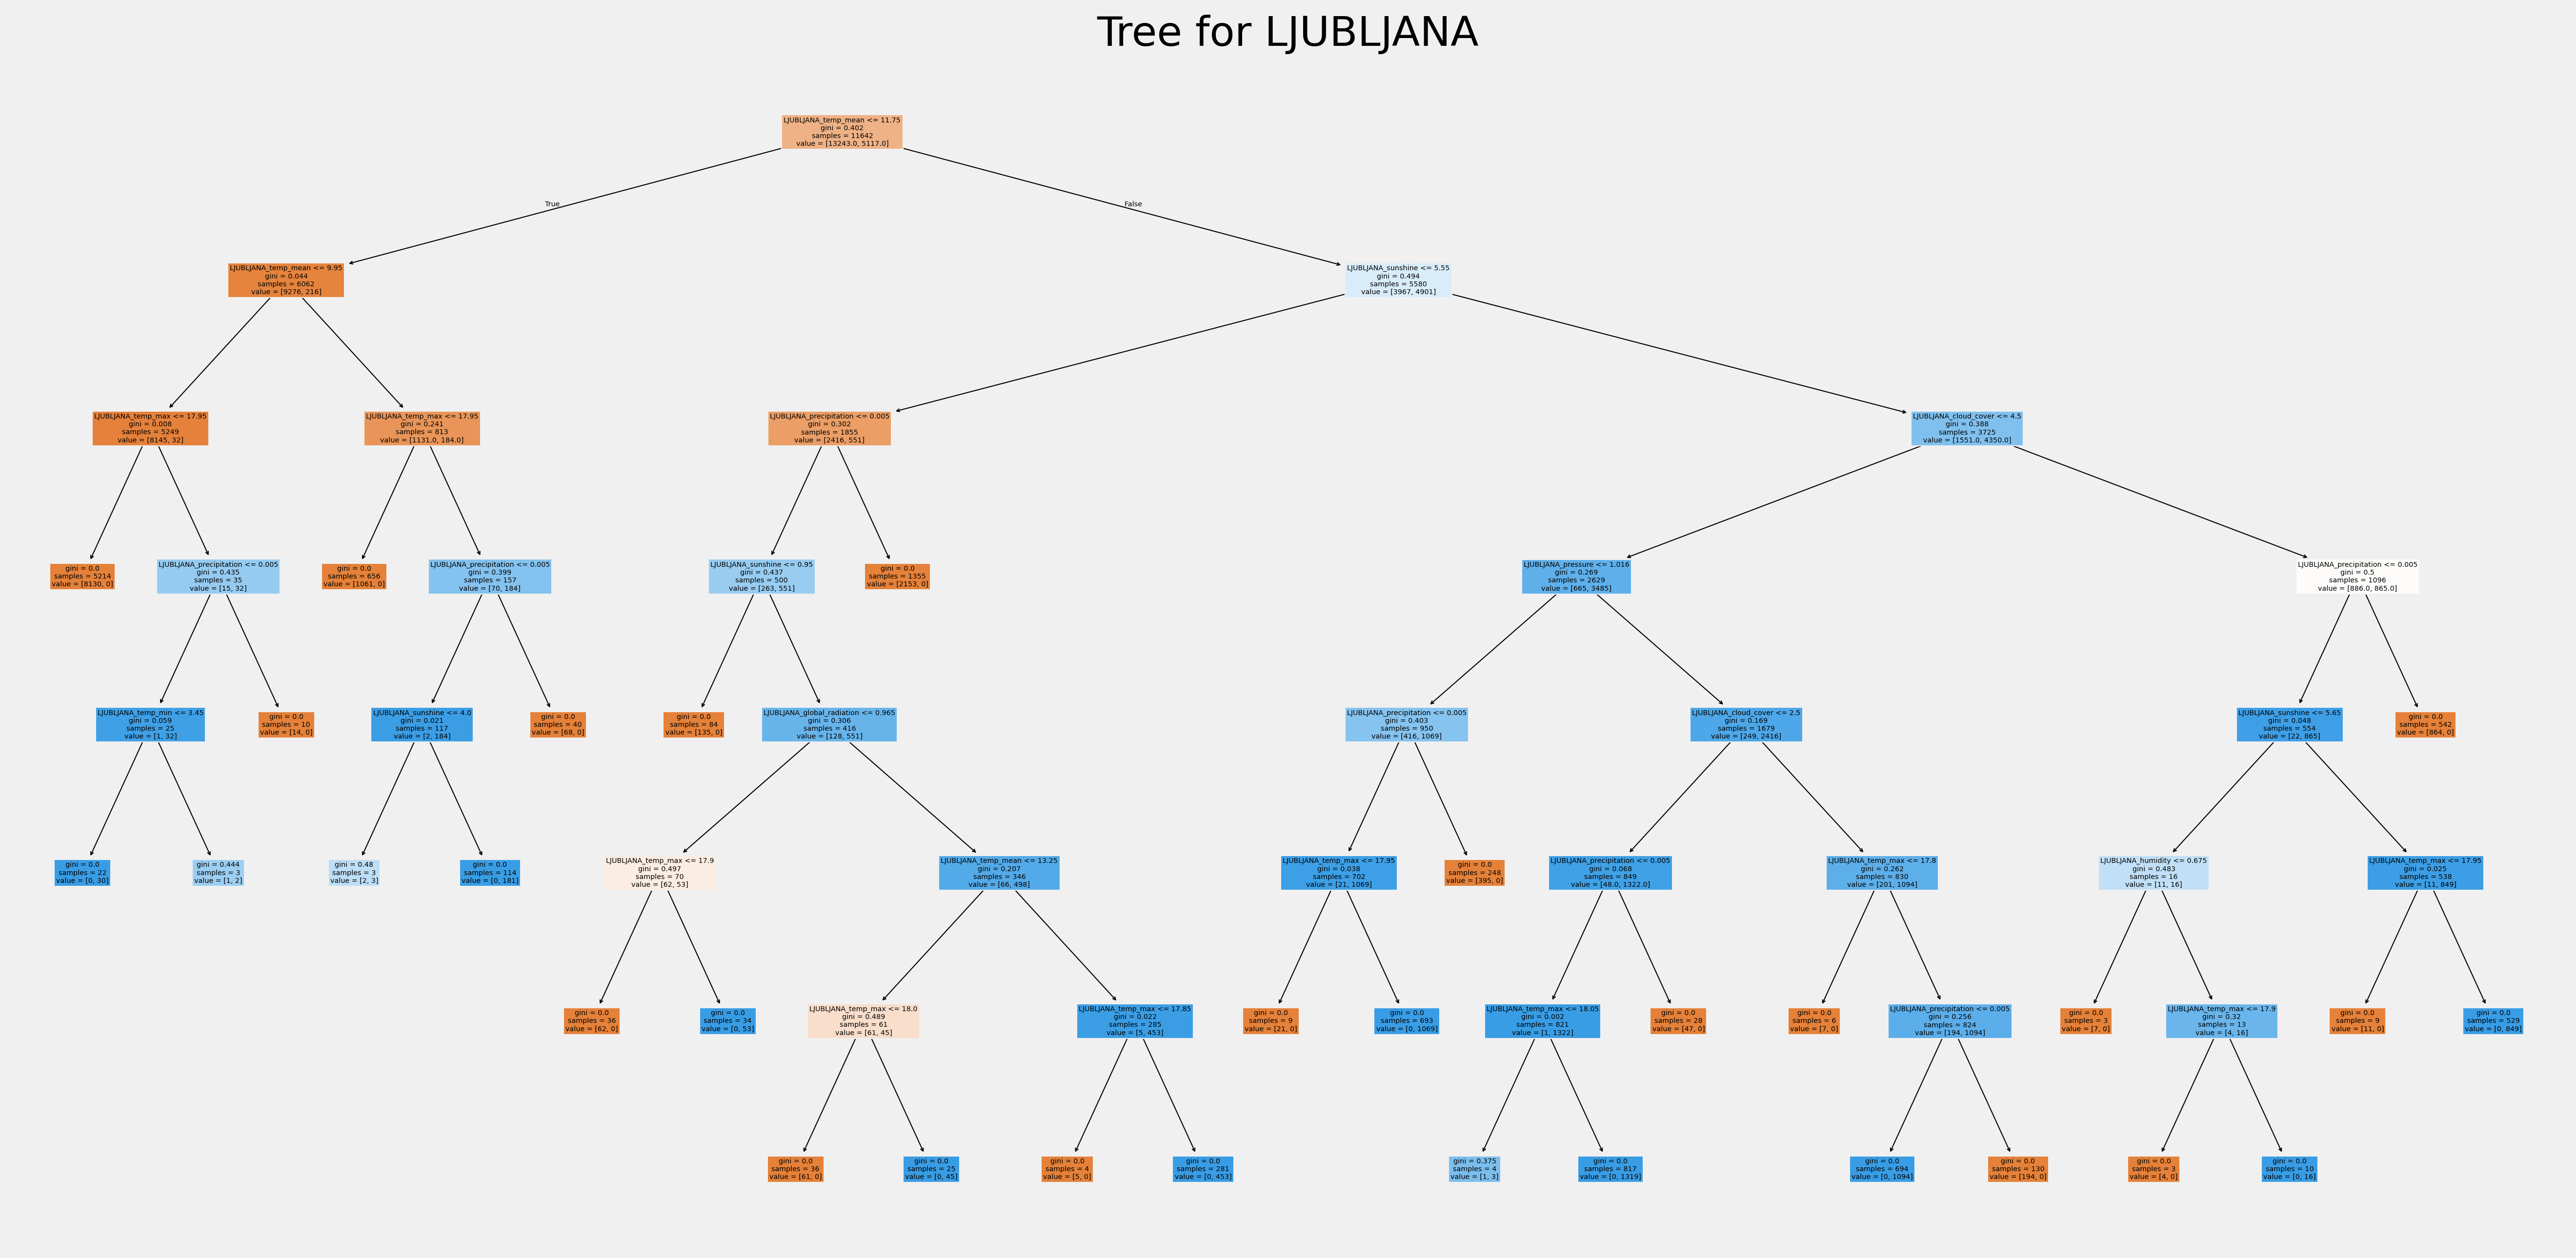

Optimized Model Accuracy for DEBILT: 1.0


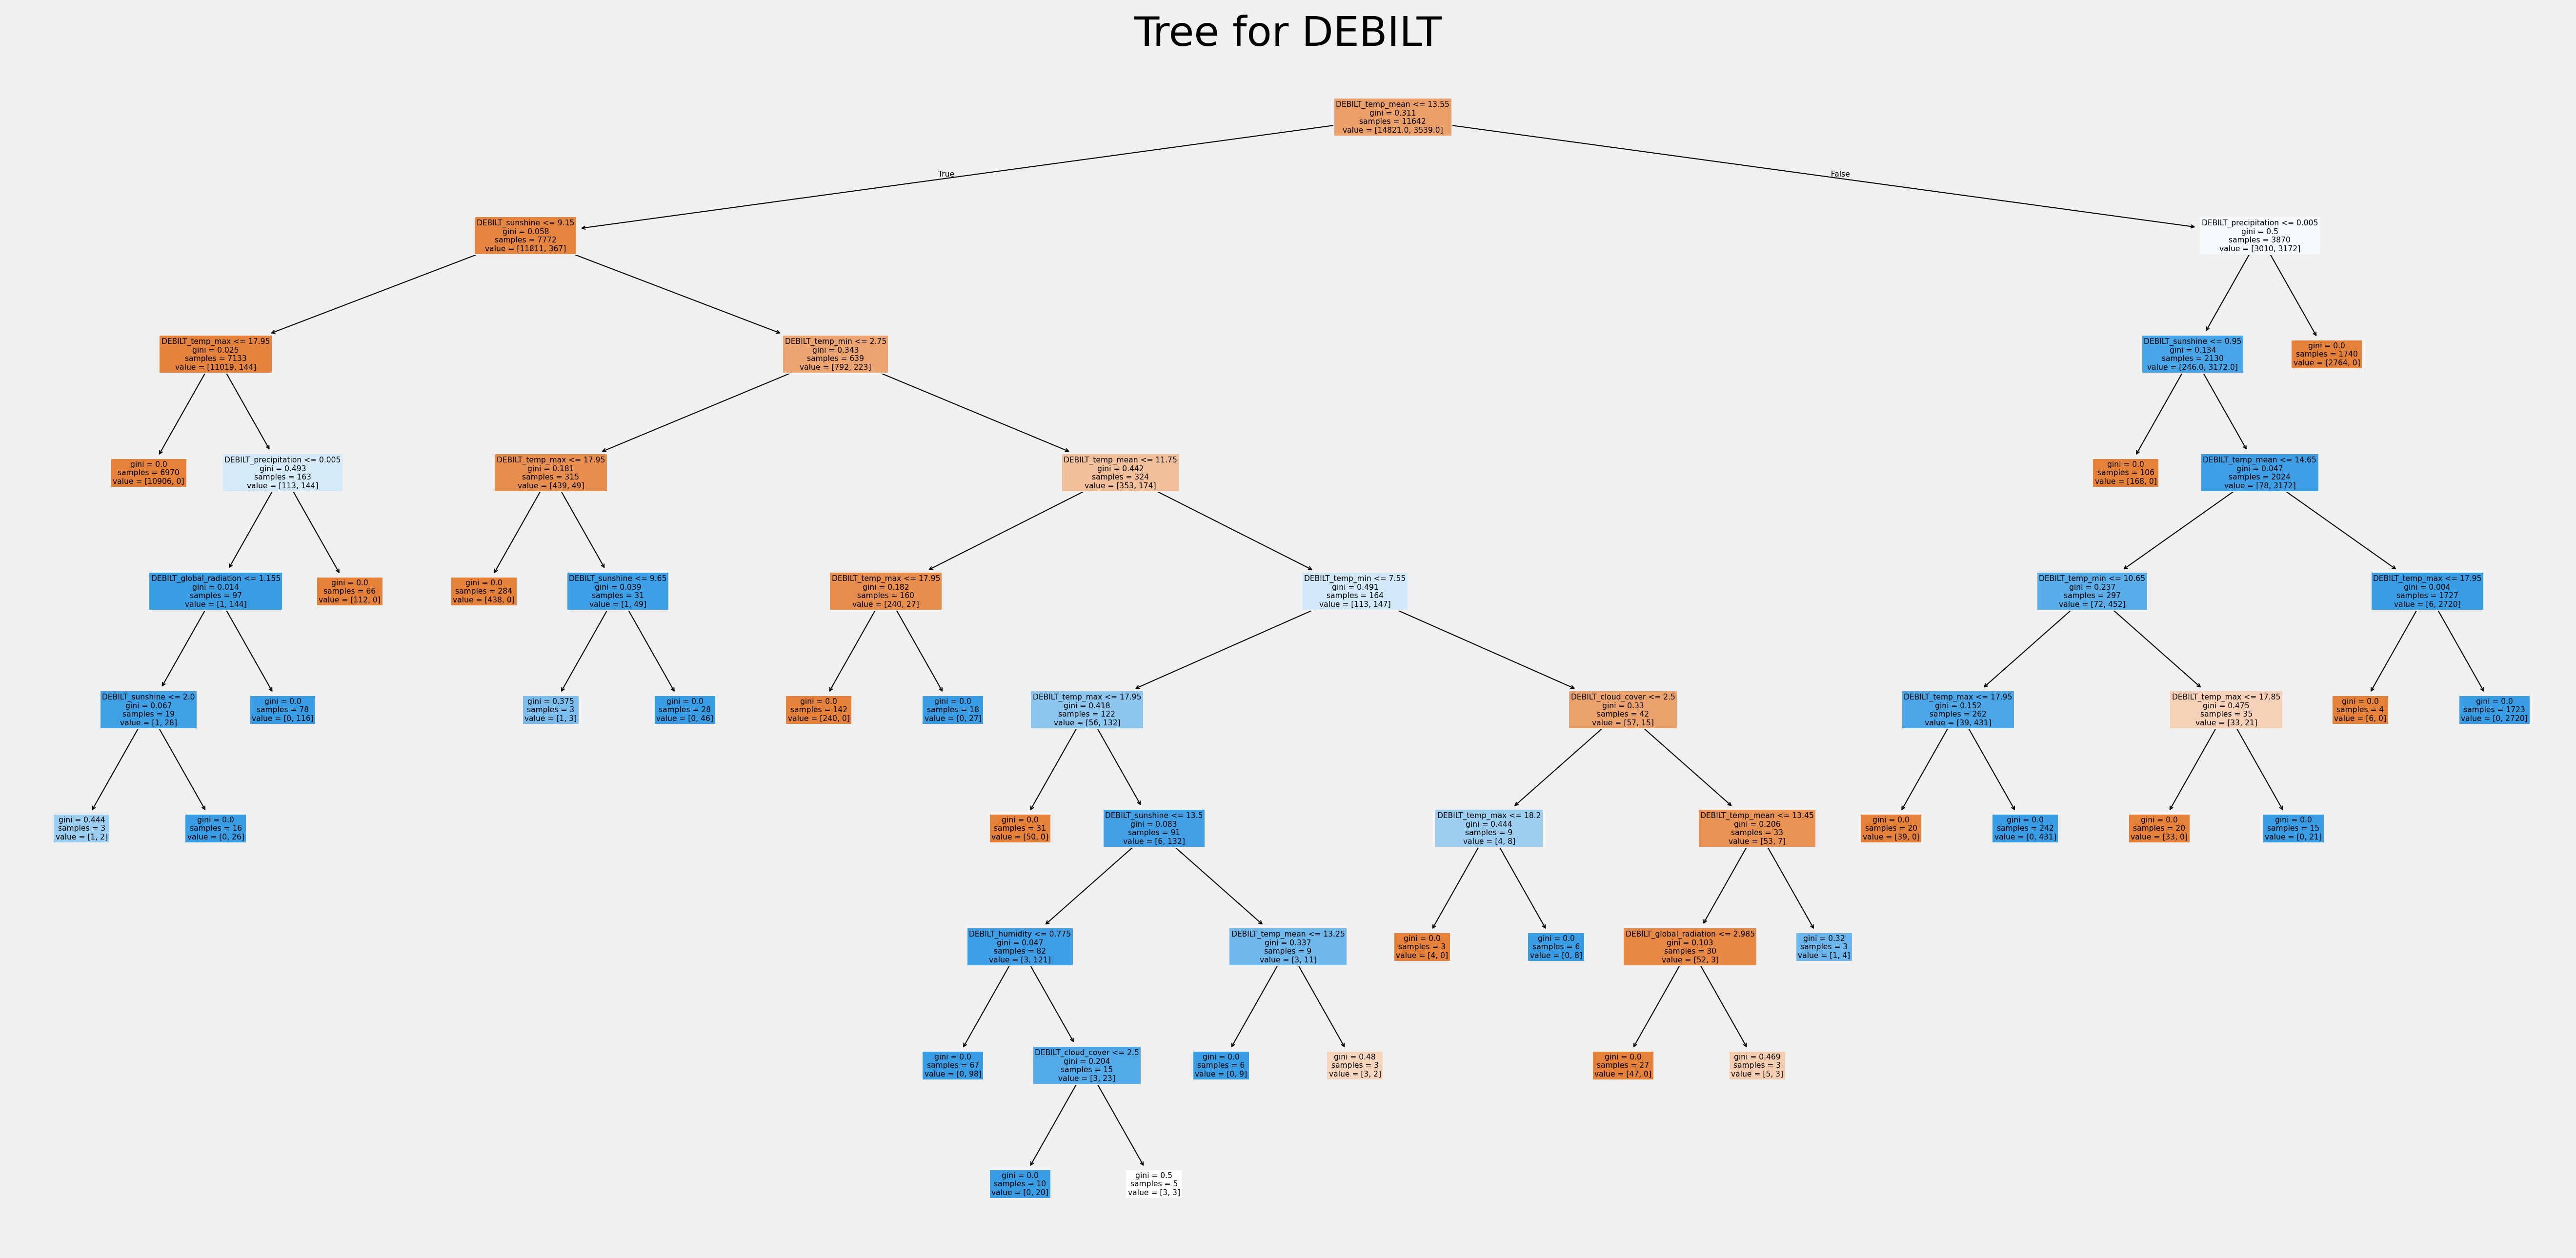

In [63]:
# Train random forest model for each top station with the best parameters
for station_name, subset in subsets.items():
    # Ensure the target variable matches the shape of the features for the entire period
    y_station = df_rate[f"{station_name}_pleasant_weather"].values
    X_station = subset.values

    # Check if the shapes of X_station and y_station are consistent
    if X_station.shape[0] != y_station.shape[0]:
        print(f"Shape mismatch for {station_name}: X_station shape = {X_station.shape}, y_station shape = {y_station.shape}")
        continue

    X_train, X_test, y_train, y_test = train_test_split(X_station, y_station, test_size=0.2, random_state=42)

    # Retrieve the optimized parameters for each station
    optimized_params = best_params_dict[station_name]

    # Initialize the RandomForestClassifier with optimized parameters
    clf_optimized = RandomForestClassifier(
        max_depth=optimized_params['max_depth'],
        n_estimators=optimized_params['n_estimators'],
        max_features=optimized_params['max_features'],
        min_samples_leaf=optimized_params['min_samples_leaf'],
        min_samples_split=optimized_params['min_samples_split'],
        criterion=optimized_params['criterion'],
        random_state=42
    )

    # Fit the model to the training data
    clf_optimized.fit(X_train, y_train)

    # Predict and evaluate the model with the optimized parameters
    y_pred_optimized = clf_optimized.predict(X_test)
    accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

    print(f"Optimized Model Accuracy for {station_name}: {accuracy_optimized}")

    # Plot one of the trees
    plt.figure(figsize=(20, 10), dpi=300)
    plot_tree(clf_optimized.estimators_[0], feature_names=subset.columns, filled=True)
    plt.title(f"Tree for {station_name}")
    plt.savefig(f'tree_{station_name}.png')
    plt.show()


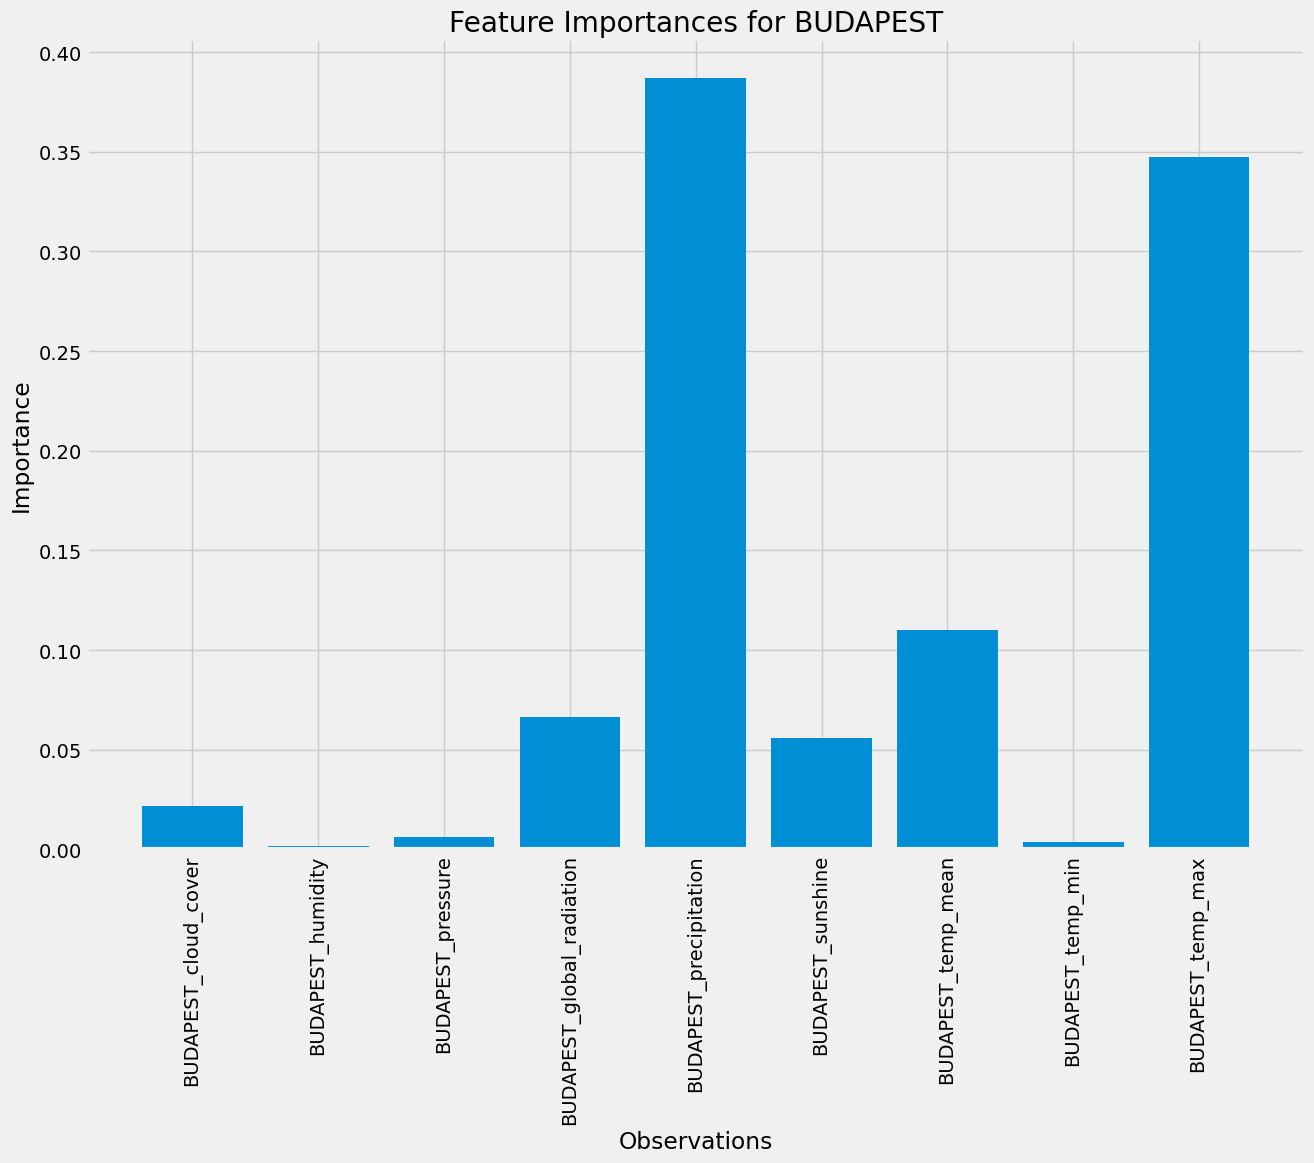

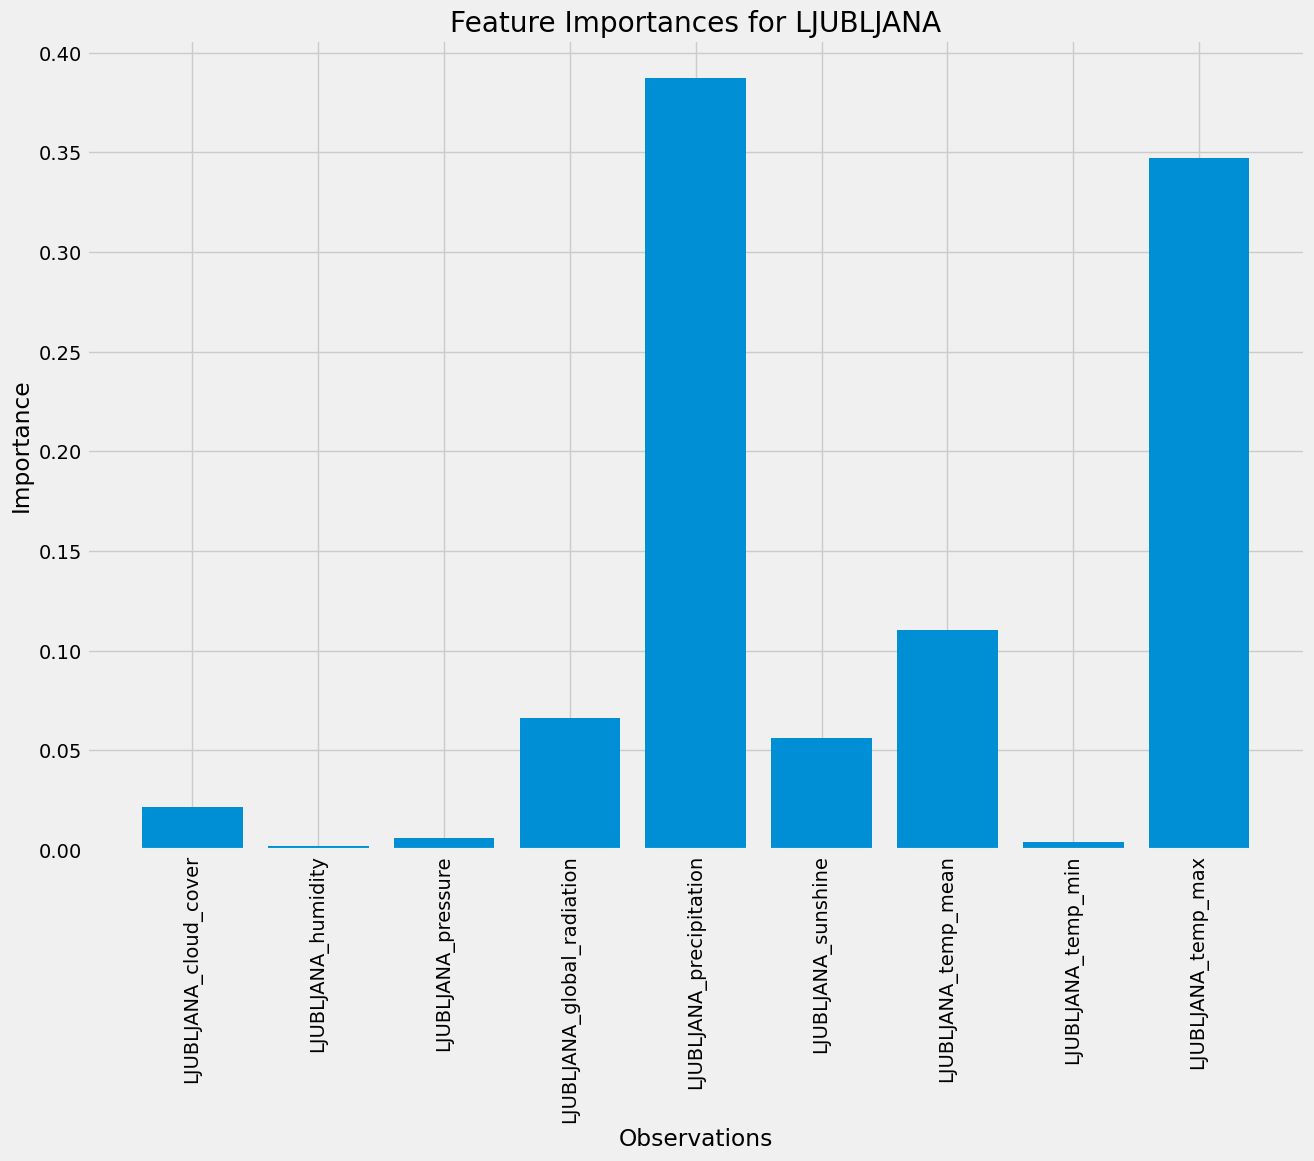

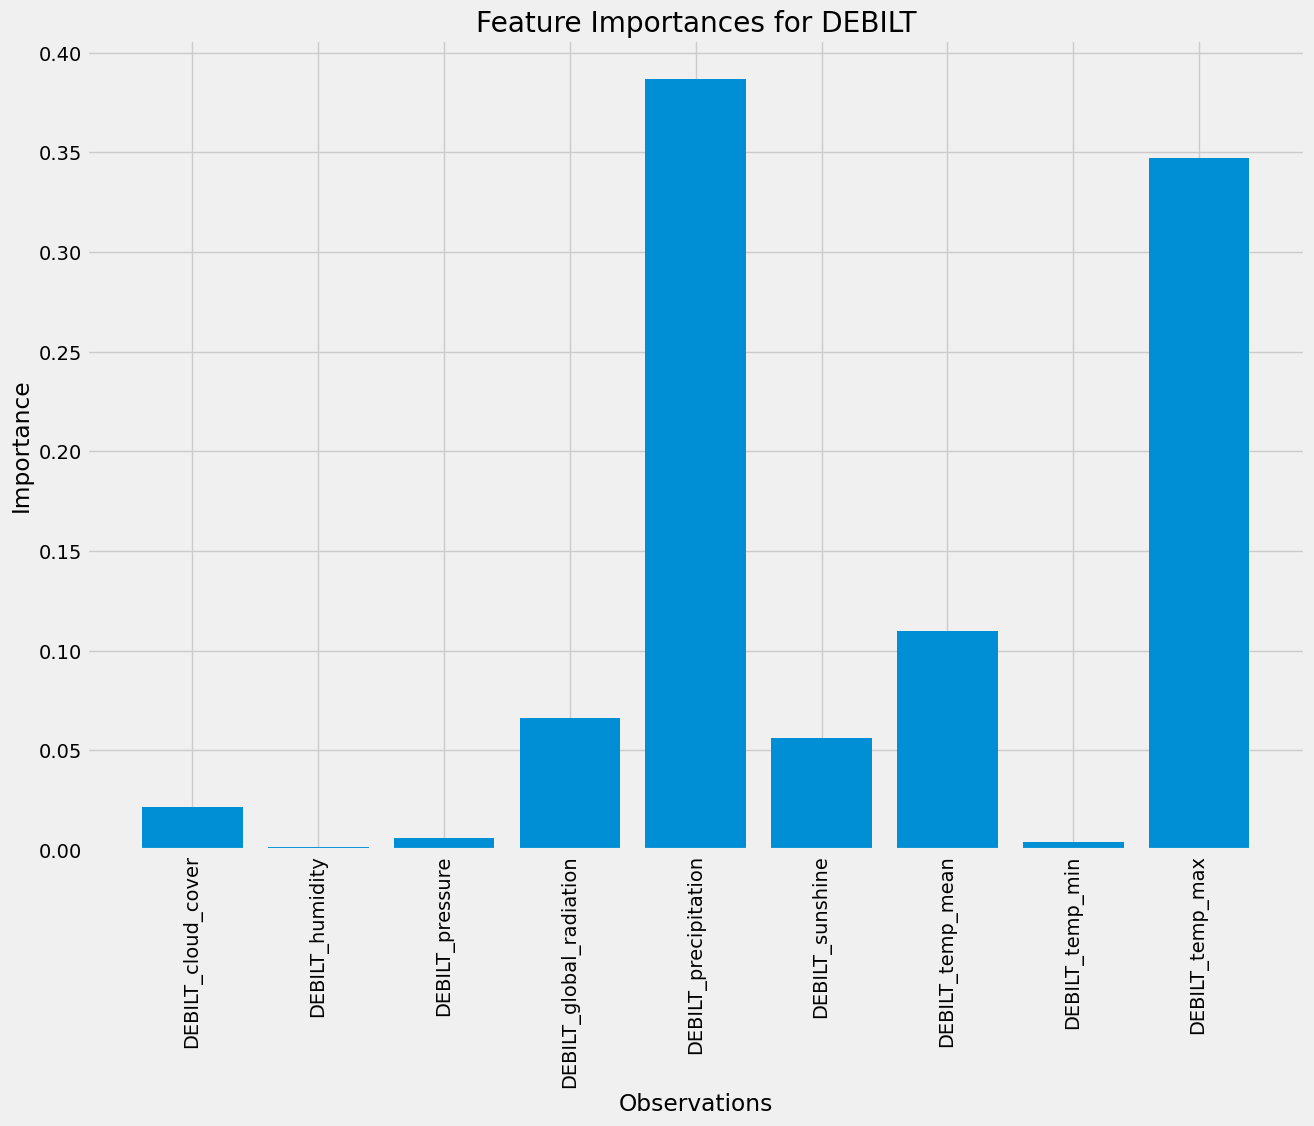

In [95]:
plt.style.use('fivethirtyeight')

# Graph the importance of the observations for each top station
for station_name, subset in subsets.items():
    # Retrieve the optimized model for each station
    best_model_random = random_search.best_estimator_

    # Get feature importances from the optimized model
    importances_station = best_model_random.feature_importances_

    plt.figure(figsize=(14, 10))
    plt.tight_layout(pad=3.0)
    plt.bar(subset.columns, importances_station)
    plt.xlabel('Observations')
    plt.ylabel('Importance')
    plt.title(f'Feature Importances for {station_name}')
    plt.xticks(rotation=90)
    plt.savefig(f'feature_importances_{station_name}.png', bbox_inches='tight')
    plt.show()


Once optimized, the accuracy scores didn't change much, however there is a difference in the top 3 stations and the weather observations, having the precipitations even more important for the model predicitve capabilities.